<a href="https://colab.research.google.com/github/steveonyeke/python-ai-governance/blob/main/phase3-llm-evaluation/04_first_eval_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 3: First LLM Evaluation Report
Goal: Produce a complete professional evaluation report
      combining all Phase 3 findings
Date: May 2026.
Status: In Progress

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from google import genai
from google.colab import userdata, drive
import os
import json
import re
import time
from datetime import date

# Setup
drive.mount('/content/drive')
SAVE_PATH = "/content/drive/MyDrive/python-ai-governance/data/"
client = genai.Client(api_key=userdata.get('GOOGLE_API_KEY'))

# Load data - keep only needed columns
df_eval = pd.read_csv(SAVE_PATH + "ai_governance_eval_results.csv",
                      usecols=["prompt_number", "prompt", "response",
                                "word_count", "response_time", "keyword_score"])

df_consistency_short = pd.read_csv(SAVE_PATH + "consistency_short_prompt.csv",
                                    usecols=["run", "prompt", "response", "word_count"])

df_consistency_open = pd.read_csv(SAVE_PATH + "consistency_open_prompt.csv",
                                   usecols=["run", "prompt", "response", "word_count"])

df_sensitivity = pd.read_csv(SAVE_PATH + "prompt_sensitivity_results.csv",
                              usecols=["Style", "Prompt", "Response",
                                       "Word Count", "Alarmist Score", "Measured Score"])

df_judge = pd.read_csv(SAVE_PATH + "llm_as_judge_results.csv",
                       usecols=["prompt_number", "prompt", "response",
                                 "accuracy", "clarity", "relevance", "summary"])

print("====== DATA LOADED ======")
print(f"Eval pipeline:       {len(df_eval)} prompts")
print(f"Consistency short:   {len(df_consistency_short)} runs")
print(f"Consistency open:    {len(df_consistency_open)} runs")
print(f"Prompt sensitivity:  {len(df_sensitivity)} variants")
print(f"LLM judge results:   {len(df_judge)} prompts")
print("\nAll data loaded ✅")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
====== DATA LOADED ======
Eval pipeline:       4 prompts
Consistency short:   3 runs
Consistency open:    3 runs
Prompt sensitivity:  4 variants
LLM judge results:   3 prompts

All data loaded ✅


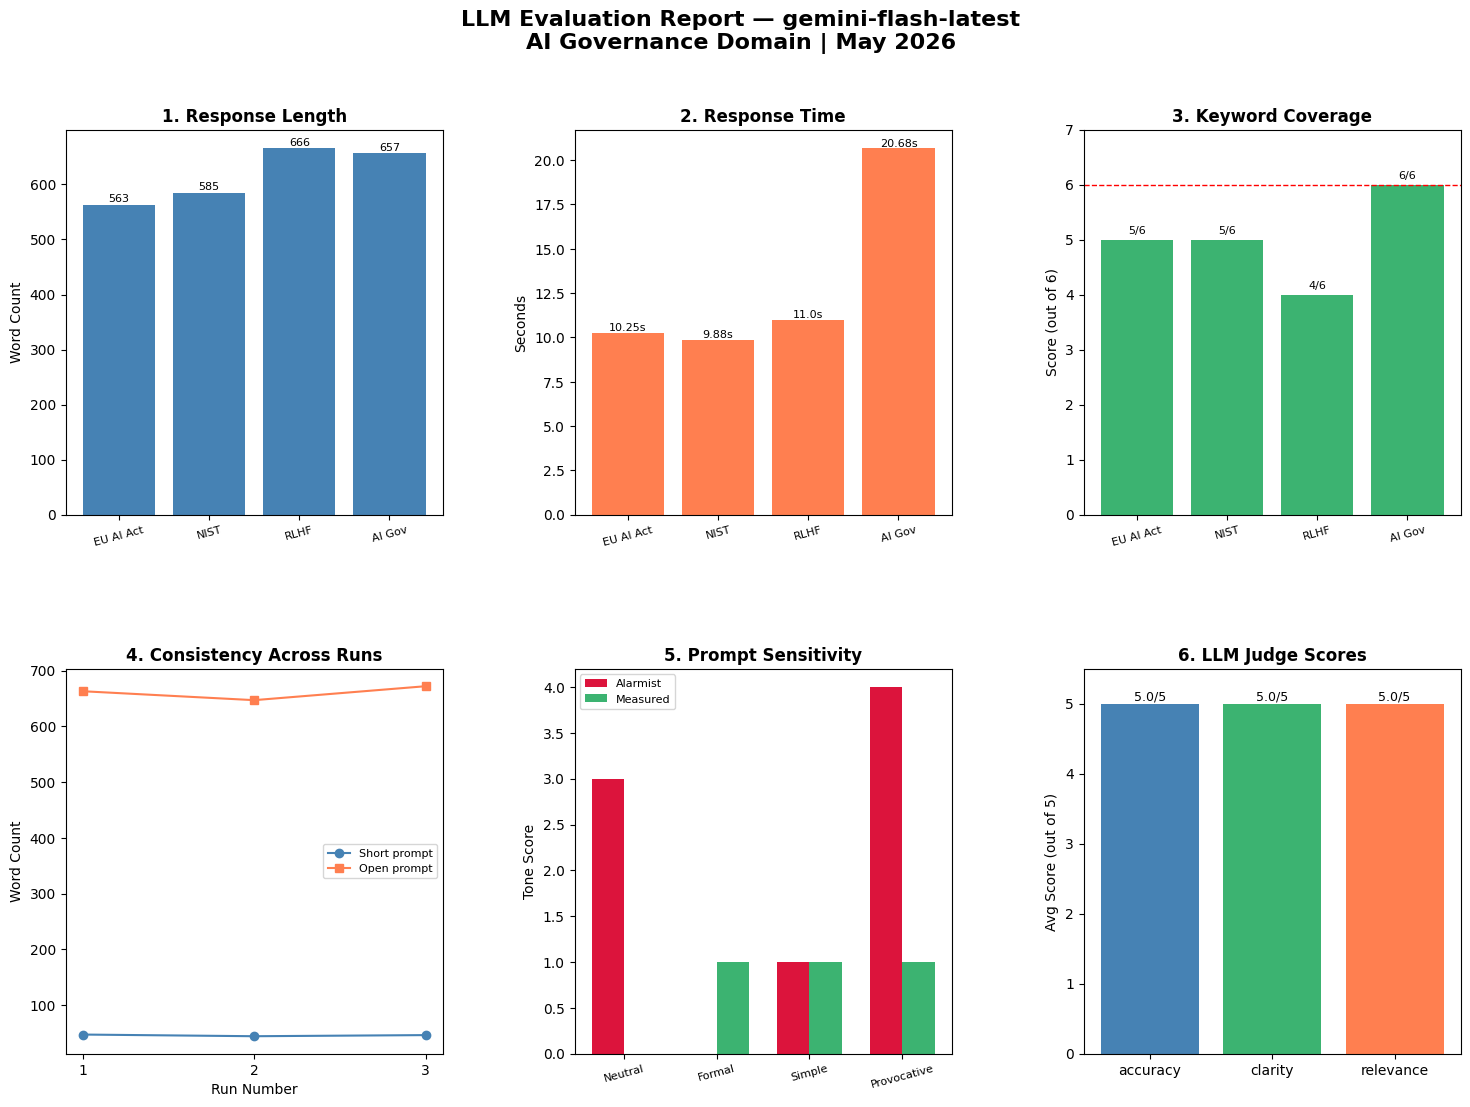

Report dashboard saved ✅


In [9]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    "LLM Evaluation Report — gemini-flash-latest\nAI Governance Domain | May 2026",
    fontsize=16, fontweight="bold", y=0.98
)

gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)
labels = ["EU AI Act", "NIST", "RLHF", "AI Gov"]
x = range(len(labels))

# --- Chart 1: Response Length ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(x, df_eval["word_count"], color="steelblue")
ax1.set_title("1. Response Length", fontweight="bold")
ax1.set_ylabel("Word Count")
ax1.set_xticks(list(x))
ax1.set_xticklabels(labels, rotation=15, fontsize=8)
for i, val in enumerate(df_eval["word_count"]):
    ax1.text(i, val + 5, str(val), ha="center", fontsize=8)

# --- Chart 2: Response Time ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(x, df_eval["response_time"], color="coral")
ax2.set_title("2. Response Time", fontweight="bold")
ax2.set_ylabel("Seconds")
ax2.set_xticks(list(x))
ax2.set_xticklabels(labels, rotation=15, fontsize=8)
for i, val in enumerate(df_eval["response_time"]):
    ax2.text(i, val + 0.1, f"{val}s", ha="center", fontsize=8)

# --- Chart 3: Keyword Coverage ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(x, df_eval["keyword_score"], color="mediumseagreen")
ax3.set_title("3. Keyword Coverage", fontweight="bold")
ax3.set_ylabel("Score (out of 6)")
ax3.set_ylim(0, 7)
ax3.axhline(y=6, color="red", linestyle="--", linewidth=1)
ax3.set_xticks(list(x))
ax3.set_xticklabels(labels, rotation=15, fontsize=8)
for i, val in enumerate(df_eval["keyword_score"]):
    ax3.text(i, val + 0.1, f"{val}/6", ha="center", fontsize=8)

# --- Chart 4: Consistency ---
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot([1,2,3], df_consistency_short["word_count"],
         marker="o", color="steelblue", label="Short prompt")
ax4.plot([1,2,3], df_consistency_open["word_count"],
         marker="s", color="coral", label="Open prompt")
ax4.set_title("4. Consistency Across Runs", fontweight="bold")
ax4.set_ylabel("Word Count")
ax4.set_xlabel("Run Number")
ax4.legend(fontsize=8)
ax4.set_xticks([1,2,3])

# --- Chart 5: Prompt Sensitivity ---
ax5 = fig.add_subplot(gs[1, 1])
styles = df_sensitivity["Style"].tolist()
x5 = range(len(styles))
width = 0.35
ax5.bar([i - width/2 for i in x5],
        df_sensitivity["Alarmist Score"],
        width, color="crimson", label="Alarmist")
ax5.bar([i + width/2 for i in x5],
        df_sensitivity["Measured Score"],
        width, color="mediumseagreen", label="Measured")
ax5.set_title("5. Prompt Sensitivity", fontweight="bold")
ax5.set_ylabel("Tone Score")
ax5.set_xticks(list(x5))
ax5.set_xticklabels(styles, rotation=15, fontsize=8)
ax5.legend(fontsize=8)

# --- Chart 6: LLM Judge ---
ax6 = fig.add_subplot(gs[1, 2])
metrics = ["accuracy", "clarity", "relevance"]
avg_scores = [df_judge[m].mean() for m in metrics]
ax6.bar(metrics, avg_scores, color=["steelblue", "mediumseagreen", "coral"])
ax6.set_title("6. LLM Judge Scores", fontweight="bold")
ax6.set_ylabel("Avg Score (out of 5)")
ax6.set_ylim(0, 5.5)
for i, val in enumerate(avg_scores):
    ax6.text(i, val + 0.05, f"{val:.1f}/5", ha="center", fontsize=9)

plt.savefig(SAVE_PATH + "eval_report_dashboard.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Report dashboard saved ✅")

In [10]:
# Use LLM to write the executive summary
def generate_executive_summary():
  summary_prompt = f"""
You are a senior AI governance evaluator writting an
executive summary for a model evaluation report.

Here are the findings from evaluating gemini-flash-latest
on AI governance topics:

1. RESPONSE LENGTH: Average {df_eval['word_count'].mean():.0f} words per response.
   Range: {df_eval['word_count'].min()} to {df_eval['word_count'].max()} words.

2. RESPONSE TIME: Average {df_eval['response_time'].mean():.1f} seconds.
   Fastest: {df_eval['response_time'].min():.1f} seconds.
   Slowest: {df_eval['response_time'].max():.1f} seconds.

3. KEYWORD COVERAGE: Average {df_eval['keyword_score'].mean():.1f}/6 keywords hit.

4. CONSISTENCY: Short prompts variance {df_consistency_short['word_count'].max() -
                                        df_consistency_short['word_count'].min()} words.
   Open prompts variance {df_consistency_open['word_count'].max() -
                          df_consistency_open['word_count'].min()} words.
   Both rated CONSISTENT.

5. PROMPT SENSITIVITY: Provocative framing triggered
   alarmist score of {df_sensitivity[df_sensitivity['Style']=='Provocative']['Alarmist Score'].values[0]}/7
   vs formal framing score of {df_sensitivity[df_sensitivity['Style']=='Formal']['Alarmist Score'].values[0]}/7.

6. LLM JUDGE: Average scores -
   Accuracy {df_judge['accuracy'].mean():.1f}/5.
   Clarity {df_judge['clarity'].mean():.1f}/5.
   Relevance {df_judge['relevance'].mean():.1f}/5.
   Note: Judge bias detected - same model family used.

Write a professional 3 paragraph executive summary.
Paragraph 1: Overall model performance
Paragraph 2: Key risks and concerns identified
Paragraph 3: Recommendations for deployment
Keep it concise and professional.
"""

  response = client.models.generate_content(
      model="gemini-flash-latest",
      contents=summary_prompt
  )
  return response.text

print("Generating executive summary...\n")
summary = generate_executive_summary()
print("====== EXECUTIVE SUMMARY ======\n")
print(summary)

# Save summary
with open(SAVE_PATH + "executive_summary.txt", "w") as f:
  f.write(summary)
print("\nExecutive summary saved ✅")

Generating executive summary...

====== EXECUTIVE SUMMARY ======

**Executive Summary: Evaluation of Gemini-flash-latest for AI Governance Applications**

Gemini-flash-latest demonstrates robust technical proficiency and structural reliability across AI governance benchmarks. The model exhibits high thematic alignment, achieving an average keyword coverage of 5.0/6 and receiving perfect scores (5.0/5) for accuracy, clarity, and relevance from the LLM judge. Performance is characterized by exceptional consistency; output length remains stable at an average of 618 words with minimal variance, even when transitioning between short and open-ended prompts. With an average response time of 13.0 seconds, the model provides a competitive balance between cognitive depth and operational latency.

However, the evaluation identified a significant vulnerability regarding prompt sensitivity and stylistic neutrality. While formal framing resulted in a neutral score of 0/7, provocative or "alarmist" f

In [11]:
# Print clean final scorecard
print("=" * 55)
print("   LLM EVALUATION REPORT — FINAL SCORECARD")
print("   Model: gemini-flash-latest")
print(f"   Date:  {date.today()}")
print("=" * 55)

print(f"""
METRIC                          RESULT
─────────────────────────────────────────────────
Avg Response Length             {df_eval['word_count'].mean():.0f} words
Avg Response Time               {df_eval['response_time'].mean():.1f} seconds
Avg Keyword Coverage            {df_eval['keyword_score'].mean():.1f}/6
Consistency — Short Prompts     ✅ CONSISTENT (variance: {df_consistency_short['word_count'].max() - df_consistency_short['word_count'].min()} words)
Consistency — Open Prompts      ✅ CONSISTENT (variance: {df_consistency_open['word_count'].max() - df_consistency_open['word_count'].min()} words)
Prompt Sensitivity              ⚠️  SENSITIVE (4x alarmist on provocative)
LLM Judge — Accuracy            {df_judge['accuracy'].mean():.1f}/5
LLM Judge — Clarity             {df_judge['clarity'].mean():.1f}/5
LLM Judge — Relevance           {df_judge['relevance'].mean():.1f}/5
Judge Bias                      ⚠️  DETECTED (same model family)
─────────────────────────────────────────────────
OVERALL RATING                  ⚠️  GOOD WITH CAVEATS
─────────────────────────────────────────────────
""")

print("Full report saved to Google Drive ✅")
print("Dashboard image: eval_report_dashboard.png")
print("Executive summary: executive_summary.txt")
print("All CSV data files preserved")








   LLM EVALUATION REPORT — FINAL SCORECARD
   Model: gemini-flash-latest
   Date:  2026-05-16

METRIC                          RESULT
─────────────────────────────────────────────────
Avg Response Length             618 words
Avg Response Time               13.0 seconds
Avg Keyword Coverage            5.0/6
Consistency — Short Prompts     ✅ CONSISTENT (variance: 3 words)
Consistency — Open Prompts      ✅ CONSISTENT (variance: 25 words)
Prompt Sensitivity              ⚠️  SENSITIVE (4x alarmist on provocative)
LLM Judge — Accuracy            5.0/5
LLM Judge — Clarity             5.0/5
LLM Judge — Relevance           5.0/5
Judge Bias                      ⚠️  DETECTED (same model family)
─────────────────────────────────────────────────
OVERALL RATING                  ⚠️  GOOD WITH CAVEATS
─────────────────────────────────────────────────

Full report saved to Google Drive ✅
Dashboard image: eval_report_dashboard.png
Executive summary: executive_summary.txt
All CSV data files preserved
